In [1]:
from torchvision.datasets import MNIST
from jaxtyping import Array, Float, Int, Key
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from optax import softmax_cross_entropy_with_integer_labels as cross_entropy


In [2]:
train_dataset = MNIST(root="./data", train=True)
test_dataset = MNIST(root="./data", train=False)
train_data = jnp.array(train_dataset.data).reshape(-1, 100, 28 * 28) / 255.0
train_labels = jnp.array(train_dataset.targets).reshape(-1, 100)
test_data = jnp.array(test_dataset.data).reshape(-1, 100, 28 * 28) / 255.0
test_labels = jnp.array(test_dataset.targets).reshape(-1, 100)
print("train", train_data.shape, train_labels.shape)
print("test", test_data.shape, test_labels.shape)

train (600, 100, 784) (600, 100)
test (100, 100, 784) (100, 100)


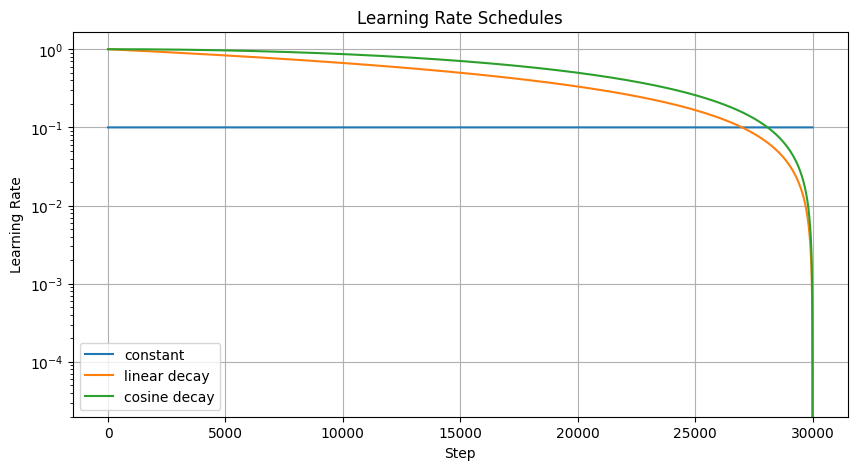

In [3]:
EPOCHS = 50
TOTAL_STEPS = len(train_data) * EPOCHS 


def constant(step: int, lr: float = 1e-1):
    return lr


def linear_decay(step: int, lr: float = 1e0):
    t = step / (TOTAL_STEPS - 1)
    return lr * (1 - t)


def cosine_decay(step: int, lr: float = 1e0):
    t = step / (TOTAL_STEPS - 1)
    return lr * jnp.cos(jnp.pi / 2 * t)


plt.figure(figsize=(10, 5))
plt.plot(jax.vmap(constant)(jnp.arange(TOTAL_STEPS)), label="constant")
plt.plot(linear_decay(jnp.arange(TOTAL_STEPS)), label="linear decay")
plt.plot(cosine_decay(jnp.arange(TOTAL_STEPS)), label="cosine decay")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedules")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

In [4]:
def simulation(
    scheduler,
    activation=jax.nn.relu,
    train_data=train_data,
    train_labels=train_labels,
    test_data=test_data,
    test_labels=test_labels,
):
    seed = 0
    key_init, key_train = jr.split(jr.key(seed))
    network = eqx.nn.MLP(
        in_size=28 * 28,
        out_size=10,
        width_size=128,
        depth=2,
        activation=activation,
        scan=True,
        key=key_init,
    )

    optimizer = optax.sgd(scheduler)
    opt_state = optimizer.init(eqx.filter(network, eqx.is_inexact_array))

    @eqx.filter_jit
    def shuffle(key, train_data, train_labels):
        _, B, D = train_data.shape
        train_data = train_data.reshape(-1, D)
        train_labels = train_labels.reshape(-1)
        perm = jr.permutation(key, len(train_data))
        train_data = train_data[perm].reshape(-1, B, D)
        train_labels = train_labels[perm].reshape(-1, B)
        return train_data, train_labels

    @eqx.filter_jit
    def train_step(network, opt_state, data, labels):
        def loss_fn(network):
            logits = jax.vmap(network)(data)
            loss = cross_entropy(logits, labels)
            return loss.mean()

        loss, grads = eqx.filter_value_and_grad(loss_fn)(network)
        updates, opt_state = optimizer.update(grads, opt_state)
        network = eqx.apply_updates(network, updates)
        return network, opt_state, loss

    @eqx.filter_jit
    def eval_step(network, data, labels):
        logits = jax.vmap(network)(data)
        loss = cross_entropy(logits, labels)
        acc = logits.argmax(axis=-1) == labels
        return loss.mean(), acc.mean()

    train_loss = []
    test_loss = []
    test_acc = []
    for key in (pbar := tqdm(jr.split(key_train, EPOCHS), desc="Epochs")):
        train_data, train_labels = shuffle(key, train_data, train_labels)

        train_loss.append([])
        for data, labels in zip(train_data, train_labels):
            network, opt_state, loss = train_step(network, opt_state, data, labels)
            train_loss[-1].append(loss.item())
            pbar.set_postfix(test_loss=loss.item())

        test_acc.append([])
        test_loss.append([])
        for data, labels in zip(test_data, test_labels):
            loss, acc = eval_step(network, data, labels)

            test_loss[-1].append(loss.item())
            test_acc[-1].append(acc)
            pbar.set_postfix(test_loss=loss.item(), test_acc=acc.item())

    return jnp.array(train_loss), jnp.array(test_loss), jnp.array(test_acc)

In [ ]:
results_constant = simulation(constant)
results_linear_decay = simulation(linear_decay)
results_cosine_decay = simulation(cosine_decay)

In [ ]:
plt.figure(figsize=(8, 8))
for label, (train_loss, test_loss, test_acc) in [
    ("constant", results_constant),
    ("linear decay", results_linear_decay),
    ("cosine decay", results_cosine_decay),
]:
    plt.subplot(3, 1, 1)
    plt.title("Train Loss")
    plt.plot(train_loss.mean(axis=1), label=f"{label}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.grid()
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.title("Test Loss")
    plt.plot(test_loss.mean(axis=1), label=f"{label}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.grid()
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.title("Test Accuracy")
    plt.plot(test_acc.mean(axis=1), label=f"{label}")
    plt.xlabel("Epoch")
    plt.grid()
    plt.legend()
    plt.ylim(None, 1)

plt.tight_layout()
plt.show()

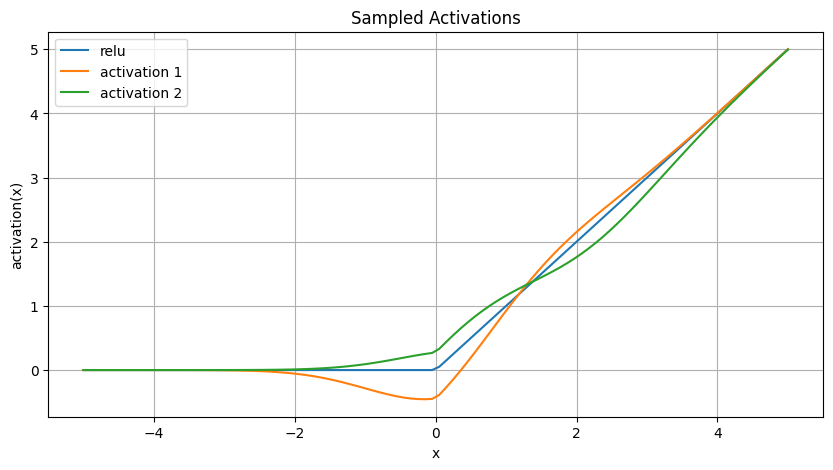

In [17]:
def make_activation(k=2):
    x = np.random.uniform(-3, 3, size=(k,))
    a = np.random.uniform(-1, 1, size=(k,))

    def activation(t):
        k = jnp.exp(-0.5 * (x - t[..., None])**2)
        return k @ a + jax.nn.relu(t)

    return activation


activation1 = make_activation()
activation2 = make_activation()

xs = jnp.linspace(-5, 5, 100)
plt.figure(figsize=(10, 5))
plt.plot(xs, jax.nn.relu(xs), label="relu")
plt.plot(xs, activation1(xs), label="activation 1")
plt.plot(xs, activation2(xs), label="activation 2")
plt.title("Sampled Activations")
plt.xlabel("x")
plt.ylabel("activation(x)")
plt.grid()
plt.legend()
plt.show()

In [ ]:
results_softplus= simulation(constant, activation=jax.nn.softplus)
results_activation1 = simulation(constant, activation=activation1)
results_activation2 = simulation(constant, activation=activation2)

Epochs: 100%|██████████| 50/50 [00:21<00:00,  2.31it/s, test_acc=0.98, test_loss=0.0511] 


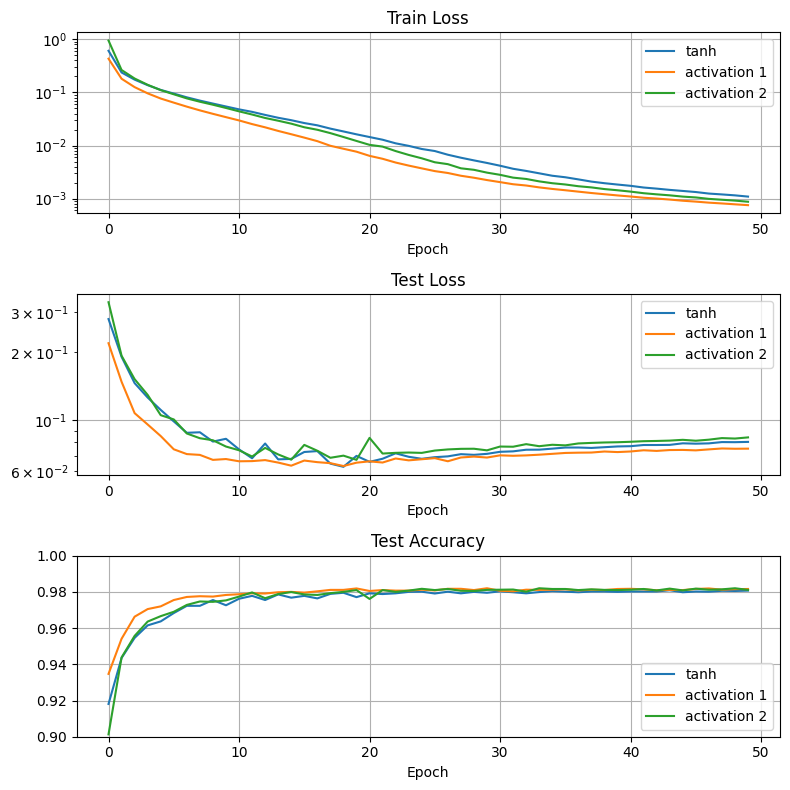

In [ ]:
plt.figure(figsize=(8, 8))
for label, (train_loss, test_loss, test_acc) in [
    ("relu", results_relu),
    ("activation 1", results_activation1),
    ("activation 2", results_activation2),
]:
    plt.subplot(3, 1, 1)
    plt.title("Train Loss")
    plt.plot(train_loss.mean(axis=1), label=f"{label}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.title("Test Loss")
    plt.plot(test_loss.mean(axis=1), label=f"{label}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.title("Test Accuracy")
    plt.plot(test_acc.mean(axis=1), label=f"{label}")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()
    plt.ylim(0.9, 1)

plt.tight_layout()
plt.show()